In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
df = pd.read_csv("Mental_Health_and_Social_Media_Balance_Dataset.csv")
df.head()

,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0


In [3]:
def descriptive_stats(data, column):
    x = data[column].dropna()
    return {
        'count': len(x),
        'mean': round(np.mean(x), 4),
        'median': round(np.median(x), 4),
        'std': round(np.std(x, ddof=1), 4),
        'min': np.min(x),
        'Q1': round(np.percentile(x, 25), 4),
        'Q3': round(np.percentile(x, 75), 4),
        'max': np.max(x),
        'IQR': round(np.percentile(x, 75) - np.percentile(x, 25), 4)
    }

In [7]:
result_full = descriptive_stats(df, 'Happiness_Index(1-10)')
print("Full Dataset Descriptive Statistics:")
for k, v in result_full.items():
    print(f"{k:<10} : {v}")

print("Skewness :", round(df['Happiness_Index(1-10)'].skew(), 4))
print("Kurtosis :", round(df['Happiness_Index(1-10)'].kurt(), 4))

Full Dataset Descriptive Statistics:
count      : 500
mean       : 8.376
median     : 9.0
std        : 1.5242
min        : 4.0
Q1         : 7.0
Q3         : 10.0
max        : 10.0
IQR        : 3.0
Skewness : -0.6888
Kurtosis : -0.2735


In [8]:
numeric_vars = [
    'Happiness_Index(1-10)',
    'Daily_Screen_Time(hrs)',
    'Sleep_Quality(1-10)',
    'Stress_Level(1-10)',
    'Days_Without_Social_Media',
    'Exercise_Frequency(week)',
    'Age'
]

summary = []

for col in numeric_vars:
    x = df[col].dropna()
    summary.append([
        col,
        round(x.mean(), 3),
        round(x.median(), 3),
        round(x.std(ddof=1), 3),
        x.min(),
        round(x.quantile(0.25), 3),
        round(x.quantile(0.75), 3),
        x.max(),
        round(x.skew(), 3)
    ])

summary_df = pd.DataFrame(summary, columns=[
    'Variable', 'Mean', 'Median', 'Std Dev', 'Min', 'Q1', 'Q3', 'Max', 'Skewness'
])

summary_df

,Variable,Mean,Median,Std Dev,Min,Q1,Q3,Max,Skewness
0,Happiness_Index(1-10),8.376,9.0,1.524,4.0,7.0,10.0,10.0,-0.689
1,Daily_Screen_Time(hrs),5.530,5.6,1.735,1.0,4.3,6.7,10.8,0.035
2,Sleep_Quality(1-10),6.304,6.0,1.530,2.0,5.0,7.0,10.0,0.032
3,Stress_Level(1-10),6.618,7.0,1.543,2.0,6.0,8.0,10.0,-0.093
4,Days_Without_Social_Media,3.134,3.0,1.859,0.0,2.0,5.0,9.0,0.080
5,Exercise_Frequency(week),2.448,2.0,1.428,0.0,1.0,3.0,7.0,0.240
6,Age,32.988,34.0,9.961,16.0,24.0,41.0,49.0,-0.122


In [9]:
sample_random = df.sample(n=150, random_state=42)

result_random = descriptive_stats(sample_random, 'Happiness_Index(1-10)')
print("Random Sample Descriptive Statistics:")
for k, v in result_random.items():
    print(f"{k:10}: {v}")

Random Sample Descriptive Statistics:
count     : 150
mean      : 8.34
median    : 9.0
std       : 1.5751
min       : 4.0
Q1        : 7.0
Q3        : 10.0
max       : 10.0
IQR       : 3.0


In [10]:
population = descriptive_stats(df, 'Happiness_Index(1-10)')
random_sample = descriptive_stats(sample_random, 'Happiness_Index(1-10)')

compare_random = pd.DataFrame({
    'Population (n=500)': population,
    'Random Sample (n=150)': random_sample
})

compare_random['Difference'] = compare_random['Random Sample (n=150)'] - compare_random['Population (n=500)']
compare_random

,Population (n=500),Random Sample (n=150),Difference
count,500.0000,150.0000,-350.0000
mean,8.3760,8.3400,-0.0360
median,9.0000,9.0000,0.0000
std,1.5242,1.5751,0.0509
min,4.0000,4.0000,0.0000
Q1,7.0000,7.0000,0.0000
Q3,10.0000,10.0000,0.0000
max,10.0000,10.0000,0.0000
IQR,3.0000,3.0000,0.0000


In [11]:
k = len(df) // 150
sample_systematic = df.iloc[::k]

result_sys = descriptive_stats(sample_systematic, 'Happiness_Index(1-10)')
print(f"Step k = {k}, Sample size = {len(sample_systematic)}")
print("Systematic Sample Descriptive Statistics:")
for key, val in result_sys.items():
    print(f"{key:10}: {val}")

Step k = 3, Sample size = 167
Systematic Sample Descriptive Statistics:
count     : 167
mean      : 8.6228
median    : 9.0
std       : 1.3693
min       : 5.0
Q1        : 8.0
Q3        : 10.0
max       : 10.0
IQR       : 2.0


In [12]:
systematic_sample = descriptive_stats(sample_systematic, 'Happiness_Index(1-10)')

compare_sys = pd.DataFrame({
    'Population (n=500)': population,
    f'Systematic Sample (n={len(sample_systematic)})': systematic_sample
})

compare_sys['Difference'] = compare_sys[f'Systematic Sample (n={len(sample_systematic)})'] - compare_sys['Population (n=500)']
compare_sys

,Population (n=500),Systematic Sample (n=167),Difference
count,500.0000,167.0000,-333.0000
mean,8.3760,8.6228,0.2468
median,9.0000,9.0000,0.0000
std,1.5242,1.3693,-0.1549
min,4.0000,5.0000,1.0000
Q1,7.0000,8.0000,1.0000
Q3,10.0000,10.0000,0.0000
max,10.0000,10.0000,0.0000
IQR,3.0000,2.0000,-1.0000


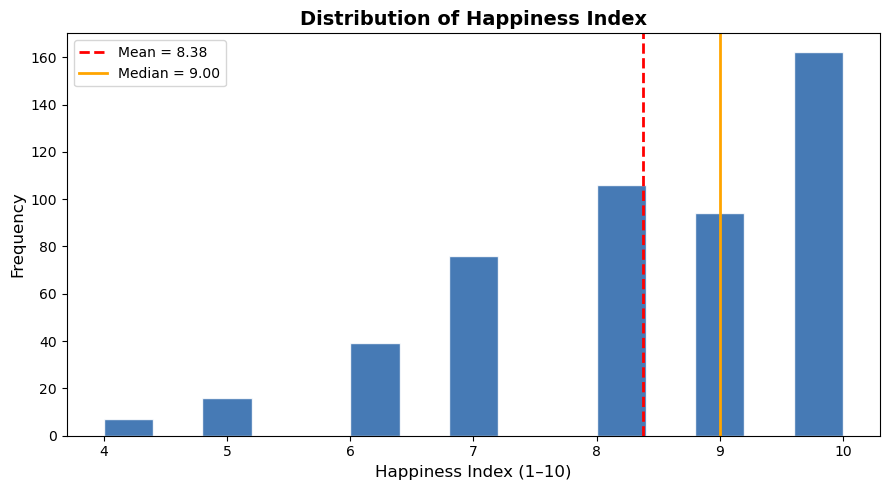

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df['Happiness_Index(1-10)'],
        bins=15,
        color='#2563A8',
        edgecolor='white',
        alpha=0.85)

ax.axvline(df['Happiness_Index(1-10)'].mean(),
           color='red',
           linestyle='--',
           linewidth=2,
           label=f"Mean = {df['Happiness_Index(1-10)'].mean():.2f}")

ax.axvline(df['Happiness_Index(1-10)'].median(),
           color='orange',
           linestyle='-',
           linewidth=2,
           label=f"Median = {df['Happiness_Index(1-10)'].median():.2f}")

ax.set_xlabel('Happiness Index (1–10)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Happiness Index', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

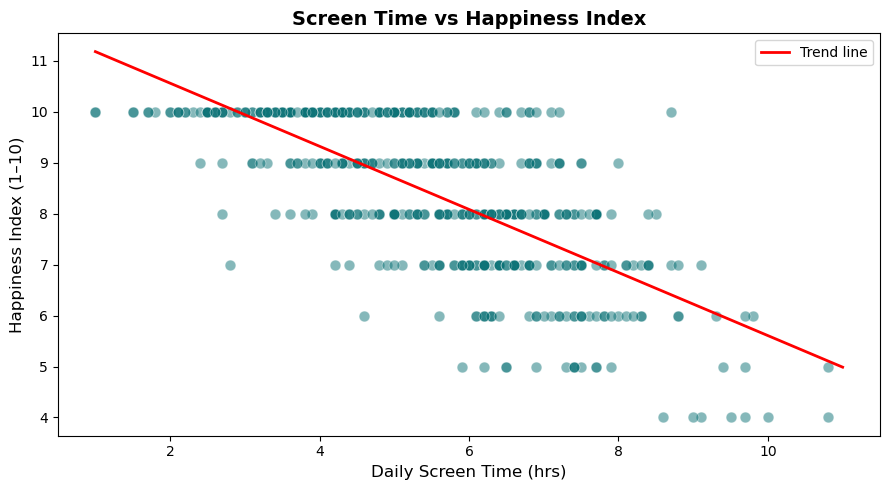

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df['Daily_Screen_Time(hrs)'],
           df['Happiness_Index(1-10)'],
           color='#0D7377',
           alpha=0.5,
           edgecolors='white',
           linewidths=0.5,
           s=60)

b, m = np.polynomial.polynomial.polyfit(
    df['Daily_Screen_Time(hrs)'],
    df['Happiness_Index(1-10)'],
    1
)

x_line = np.linspace(1, 11, 100)
ax.plot(x_line, b + m * x_line,
        color='red',
        linewidth=2,
        label='Trend line')

ax.set_xlabel('Daily Screen Time (hrs)', fontsize=12)
ax.set_ylabel('Happiness Index (1–10)', fontsize=12)
ax.set_title('Screen Time vs Happiness Index', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

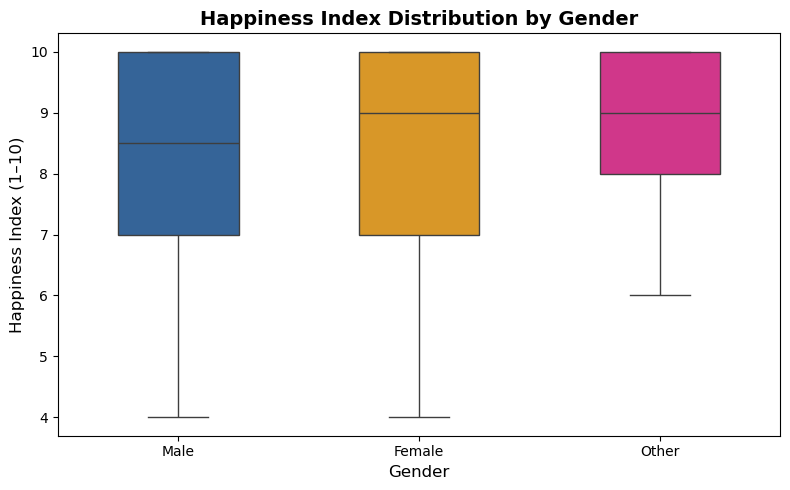

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

gender_order = ['Male', 'Female', 'Other']

sns.boxplot(
    data=df,
    x='Gender',
    y='Happiness_Index(1-10)',
    hue='Gender',                      
    order=gender_order,
    palette=['#2563A8', '#E91E8C', '#F59E0B'],
    width=0.5,
    ax=ax,
    dodge=False,                      
    legend=False                       
)

ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Happiness Index (1–10)', fontsize=12)
ax.set_title('Happiness Index Distribution by Gender', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

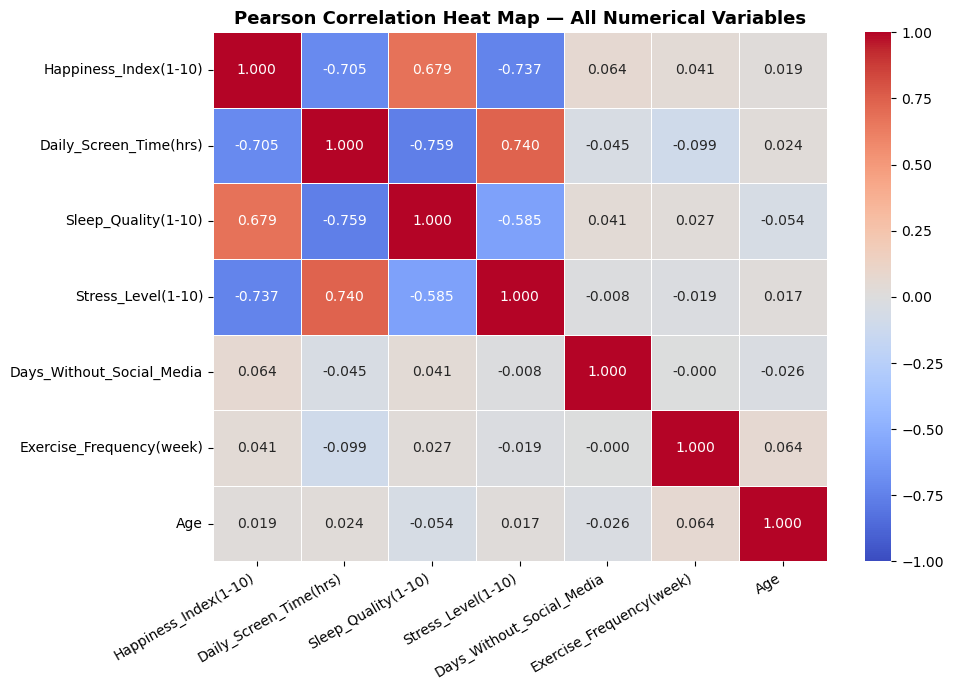

In [18]:
numeric_cols = [
    'Happiness_Index(1-10)',
    'Daily_Screen_Time(hrs)',
    'Sleep_Quality(1-10)',
    'Stress_Level(1-10)',
    'Days_Without_Social_Media',
    'Exercise_Frequency(week)',
    'Age'
]

corr_matrix = df[numeric_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 10}
)

ax.set_title('Pearson Correlation Heat Map — All Numerical Variables',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

In [19]:
r_pearson, p_pearson = stats.pearsonr(
    df['Daily_Screen_Time(hrs)'],
    df['Happiness_Index(1-10)']
)

print(f"Pearson r = {r_pearson:.4f}")
print(f"p-value   = {p_pearson:.6f}")

Pearson r = -0.7052
p-value   = 0.000000


In [20]:
rho_spearman, p_spearman = stats.spearmanr(
    df['Stress_Level(1-10)'],
    df['Happiness_Index(1-10)']
)

print(f"Spearman rho = {rho_spearman:.4f}")
print(f"p-value      = {p_spearman:.6f}")

Spearman rho = -0.7641
p-value      = 0.000000


In [21]:
df['Happiness_Category'] = df['Happiness_Index(1-10)'].apply(
    lambda x: 'High' if x >= 8 else 'Low'
)

df[['Happiness_Index(1-10)', 'Happiness_Category']].head()

,Happiness_Index(1-10),Happiness_Category
0,10.0,High
1,10.0,High
2,6.0,Low
3,8.0,High
4,8.0,High


In [22]:
contingency = pd.crosstab(df['Gender'], df['Happiness_Category'])
print("Contingency Table:")
print(contingency)

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi2 = {chi2:.4f}")
print(f"p    = {p_chi:.4f}")
print(f"df   = {dof}")

Contingency Table:
Happiness_Category  High  Low
Gender                       
Female               167   62
Male                 176   72
Other                 19    4

Chi2 = 1.4858
p    = 0.4757
df   = 2


In [23]:
contingency2 = pd.crosstab(df['Social_Media_Platform'], df['Happiness_Category'])
print("Contingency Table:")
print(contingency2)

chi2b, pb, dofb, expected2 = stats.chi2_contingency(contingency2)

print(f"\nChi2 = {chi2b:.4f}")
print(f"p    = {pb:.4f}")
print(f"df   = {dofb}")

Contingency Table:
Happiness_Category     High  Low
Social_Media_Platform           
Facebook                 57   24
Instagram                47   27
LinkedIn                 68   19
TikTok                   68   27
X (Twitter)              70   18
YouTube                  52   23

Chi2 = 7.1699
p    = 0.2083
df   = 5


In [24]:
pop_mean = df['Happiness_Index(1-10)'].mean()

sample_random = df.sample(n=150, random_state=42)
sample_mean = sample_random['Happiness_Index(1-10)'].mean()

t_stat, p_value = stats.ttest_1samp(
    sample_random['Happiness_Index(1-10)'],
    pop_mean
)

print(f"Population Mean : {pop_mean:.4f}")
print(f"Sample Mean     : {sample_mean:.4f}")
print(f"t-statistic     : {t_stat:.4f}")
print(f"p-value         : {p_value:.4f}")

if p_value > 0.05:
    print("Decision: Fail to reject H0")
else:
    print("Decision: Reject H0")

Population Mean : 8.3760
Sample Mean     : 8.3400
t-statistic     : -0.2799
p-value         : 0.7799
Decision: Fail to reject H0


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, silhouette_score

In [27]:
df = pd.read_csv("Mental_Health_and_Social_Media_Balance_Dataset.csv")
df.head()

,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0


In [28]:
numeric_cols = ['Age', 'Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)',
                'Stress_Level(1-10)', 'Days_Without_Social_Media',
                'Exercise_Frequency(week)']
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
mask = ~(((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
          (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1))
clean = df[mask].copy()

In [29]:
reg = clean.drop(columns=['User_ID']).copy()
le = LabelEncoder()
reg['Gender'] = le.fit_transform(reg['Gender'])
reg = pd.get_dummies(reg, columns=['Social_Media_Platform'], drop_first=False)

X = reg.drop(columns=['Happiness_Index(1-10)'])
y = reg['Happiness_Index(1-10)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Multiple Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(max_iter=10000),
    "Elastic Net Regression": ElasticNet(max_iter=10000)
}

Intercept: 8.840734342201365
Coefficients:
Age 0.012280444281558472
Gender 0.007616019055842814
Daily_Screen_Time(hrs) -0.039414178476839305
Sleep_Quality(1-10) 0.36624383234972674
Stress_Level(1-10) -0.46105566354077177
Days_Without_Social_Media 0.024697774969448947
Exercise_Frequency(week) 0.007783996029343782
Social_Media_Platform_Facebook 0.028993553851852323
Social_Media_Platform_Instagram -0.11350195063217663
Social_Media_Platform_LinkedIn 0.029520746827299334
Social_Media_Platform_TikTok -0.12814033731261806
Social_Media_Platform_X (Twitter) 0.08970515871111014
Social_Media_Platform_YouTube 0.09342282855452322


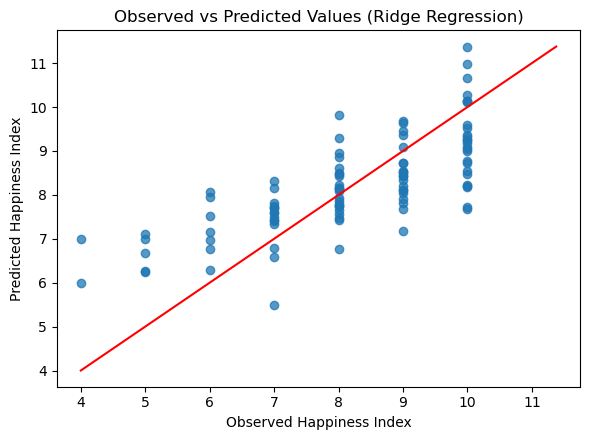

In [30]:
ridge = Ridge()
ridge.fit(X_train, y_train)
print("Intercept:", ridge.intercept_)
print("Coefficients:")
for name, coef in zip(X.columns, ridge.coef_):
    print(name, coef)

ridge_pred = ridge.predict(X_test)
plt.figure(figsize=(6, 4.5))
plt.scatter(y_test, ridge_pred, alpha=0.75)
lims = [min(y_test.min(), ridge_pred.min()), max(y_test.max(), ridge_pred.max())]
plt.plot(lims, lims, 'r-')
plt.xlabel("Observed Happiness Index")
plt.ylabel("Predicted Happiness Index")
plt.title("Observed vs Predicted Values (Ridge Regression)")
plt.tight_layout()
plt.show()

In [31]:
cls = clean.drop(columns=['User_ID']).copy()
cls['Happiness_Category'] = pd.cut(
    cls['Happiness_Index(1-10)'],
    bins=[0, 4, 7, 10],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)
cls['Gender'] = LabelEncoder().fit_transform(cls['Gender'])
X_cls = pd.get_dummies(cls.drop(columns=['Happiness_Index(1-10)', 'Happiness_Category']),
                       columns=['Social_Media_Platform'], drop_first=False)
y_cls = cls['Happiness_Category']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

scaler = StandardScaler()
Xc_train_s = scaler.fit_transform(Xc_train)
Xc_test_s = scaler.transform(Xc_test)

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(),
    "Support Vector Machine (SVM)": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200)
}
for name, clf in classifiers.items():
    clf.fit(Xc_train_s, yc_train)
    pred = clf.predict(Xc_test_s)
    print(name,
          "Accuracy=", accuracy_score(yc_test, pred),
          "Precision=", precision_score(yc_test, pred, average='weighted', zero_division=0),
          "Recall=", recall_score(yc_test, pred, average='weighted', zero_division=0),
          "F1=", f1_score(yc_test, pred, average='weighted', zero_division=0))

print(cls['Happiness_Category'].value_counts())

Logistic Regression Accuracy= 0.797979797979798 Precision= 0.781057326511872 Recall= 0.797979797979798 F1= 0.7877319051815697
K-Nearest Neighbors (KNN) Accuracy= 0.7575757575757576 Precision= 0.726040525739321 Recall= 0.7575757575757576 F1= 0.7319089512637899
Support Vector Machine (SVM) Accuracy= 0.7878787878787878 Precision= 0.7641696737822994 Recall= 0.7878787878787878 F1= 0.767188648795414
Decision Tree Accuracy= 0.7878787878787878 Precision= 0.7840745884224144 Recall= 0.7878787878787878 F1= 0.7844524830826202
Random Forest Accuracy= 0.8080808080808081 Precision= 0.7932875667429443 Recall= 0.8080808080808081 F1= 0.7996122281836567
Happiness_Category
High      359
Medium    130
Low         6
Name: count, dtype: int64


In [32]:
cluster_features = clean[['Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)','Stress_Level(1-10)', 'Days_Without_Social_Media', 'Exercise_Frequency(week)', 'Happiness_Index(1-10)']]

Z = StandardScaler().fit_transform(cluster_features)
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Z)
    print("k=", k, "silhouette=", silhouette_score(Z, labels))

km = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = km.fit_predict(Z)
print(cluster_features.assign(Cluster=labels).groupby("Cluster").mean())

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


k= 2 silhouette= 0.28292093791250705
k= 3 silhouette= 0.18617442855130623


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


k= 4 silhouette= 0.18445633513571638


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


k= 5 silhouette= 0.18368863741024055


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


k= 6 silhouette= 0.1763238413737905
         Daily_Screen_Time(hrs)  Sleep_Quality(1-10)  Stress_Level(1-10)  \
Cluster                                                                    
0                      4.290079             7.317460            5.555556   
1                      6.804115             5.259259            7.720165   

         Days_Without_Social_Media  Exercise_Frequency(week)  \
Cluster                                                        
0                         3.234127                  2.484127   
1                         3.045267                  2.382716   

         Happiness_Index(1-10)  
Cluster                         
0                     9.492063  
1                     7.230453  


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, silhouette_score
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [34]:
df = pd.read_csv("Mental_Health_and_Social_Media_Balance_Dataset.csv")
df.head()

,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0


In [35]:
numeric_cols = ['Age', 'Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)',
                'Stress_Level(1-10)', 'Days_Without_Social_Media',
                'Exercise_Frequency(week)']
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
mask = ~(((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
          (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1))
clean = df[mask].copy()

In [36]:
reg = clean.drop(columns=['User_ID']).copy()
le = LabelEncoder()
reg['Gender'] = le.fit_transform(reg['Gender'])
reg = pd.get_dummies(reg, columns=['Social_Media_Platform'], drop_first=False)

X = reg.drop(columns=['Happiness_Index(1-10)'])
y = reg['Happiness_Index(1-10)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Multiple Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(max_iter=10000),
    "Elastic Net Regression": ElasticNet(max_iter=10000)
}

Intercept: 8.840734342201365
Coefficients:
Age 0.012280444281558472
Gender 0.007616019055842814
Daily_Screen_Time(hrs) -0.039414178476839305
Sleep_Quality(1-10) 0.36624383234972674
Stress_Level(1-10) -0.46105566354077177
Days_Without_Social_Media 0.024697774969448947
Exercise_Frequency(week) 0.007783996029343782
Social_Media_Platform_Facebook 0.028993553851852323
Social_Media_Platform_Instagram -0.11350195063217663
Social_Media_Platform_LinkedIn 0.029520746827299334
Social_Media_Platform_TikTok -0.12814033731261806
Social_Media_Platform_X (Twitter) 0.08970515871111014
Social_Media_Platform_YouTube 0.09342282855452322


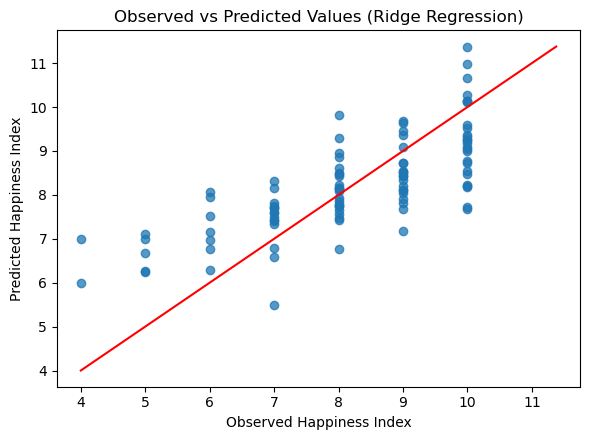

In [37]:
ridge = Ridge()
ridge.fit(X_train, y_train)
print("Intercept:", ridge.intercept_)
print("Coefficients:")
for name, coef in zip(X.columns, ridge.coef_):
    print(name, coef)

ridge_pred = ridge.predict(X_test)
plt.figure(figsize=(6, 4.5))
plt.scatter(y_test, ridge_pred, alpha=0.75)
lims = [min(y_test.min(), ridge_pred.min()), max(y_test.max(), ridge_pred.max())]
plt.plot(lims, lims, 'r-')
plt.xlabel("Observed Happiness Index")
plt.ylabel("Predicted Happiness Index")
plt.title("Observed vs Predicted Values (Ridge Regression)")
plt.tight_layout()
plt.show()

In [38]:
cls = clean.drop(columns=['User_ID']).copy()
cls['Happiness_Category'] = pd.cut(
    cls['Happiness_Index(1-10)'],
    bins=[0, 4, 7, 10],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)
cls['Gender'] = LabelEncoder().fit_transform(cls['Gender'])
X_cls = pd.get_dummies(cls.drop(columns=['Happiness_Index(1-10)', 'Happiness_Category']),
                       columns=['Social_Media_Platform'], drop_first=False)
y_cls = cls['Happiness_Category']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

scaler = StandardScaler()
Xc_train_s = scaler.fit_transform(Xc_train)
Xc_test_s = scaler.transform(Xc_test)

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(),
    "Support Vector Machine (SVM)": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200)
}

for name, clf in classifiers.items():
    clf.fit(Xc_train_s, yc_train)
    pred = clf.predict(Xc_test_s)
    print(name,
          "Accuracy=", accuracy_score(yc_test, pred),
          "Precision=", precision_score(yc_test, pred, average='weighted', zero_division=0),
          "Recall=", recall_score(yc_test, pred, average='weighted', zero_division=0),
          "F1=", f1_score(yc_test, pred, average='weighted', zero_division=0))

print(cls['Happiness_Category'].value_counts())

Logistic Regression Accuracy= 0.797979797979798 Precision= 0.781057326511872 Recall= 0.797979797979798 F1= 0.7877319051815697
K-Nearest Neighbors (KNN) Accuracy= 0.7575757575757576 Precision= 0.726040525739321 Recall= 0.7575757575757576 F1= 0.7319089512637899
Support Vector Machine (SVM) Accuracy= 0.7878787878787878 Precision= 0.7641696737822994 Recall= 0.7878787878787878 F1= 0.767188648795414
Decision Tree Accuracy= 0.7878787878787878 Precision= 0.7840745884224144 Recall= 0.7878787878787878 F1= 0.7844524830826202
Random Forest Accuracy= 0.8080808080808081 Precision= 0.7932875667429443 Recall= 0.8080808080808081 F1= 0.7996122281836567
Happiness_Category
High      359
Medium    130
Low         6
Name: count, dtype: int64


In [39]:
cluster_features = clean[['Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)','Stress_Level(1-10)', 'Days_Without_Social_Media', 'Exercise_Frequency(week)', 'Happiness_Index(1-10)']]

Z = StandardScaler().fit_transform(cluster_features)
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Z)
    print("k=", k, "silhouette=", silhouette_score(Z, labels))

km = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = km.fit_predict(Z)
print(cluster_features.assign(Cluster=labels).groupby("Cluster").mean())


k= 2 silhouette= 0.28292093791250705


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


k= 3 silhouette= 0.18617442855130623
k= 4 silhouette= 0.18445633513571638


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


k= 5 silhouette= 0.18368863741024055


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


k= 6 silhouette= 0.1763238413737905
         Daily_Screen_Time(hrs)  Sleep_Quality(1-10)  Stress_Level(1-10)  \
Cluster                                                                    
0                      4.290079             7.317460            5.555556   
1                      6.804115             5.259259            7.720165   

         Days_Without_Social_Media  Exercise_Frequency(week)  \
Cluster                                                        
0                         3.234127                  2.484127   
1                         3.045267                  2.382716   

         Happiness_Index(1-10)  
Cluster                         
0                     9.492063  
1                     7.230453  


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


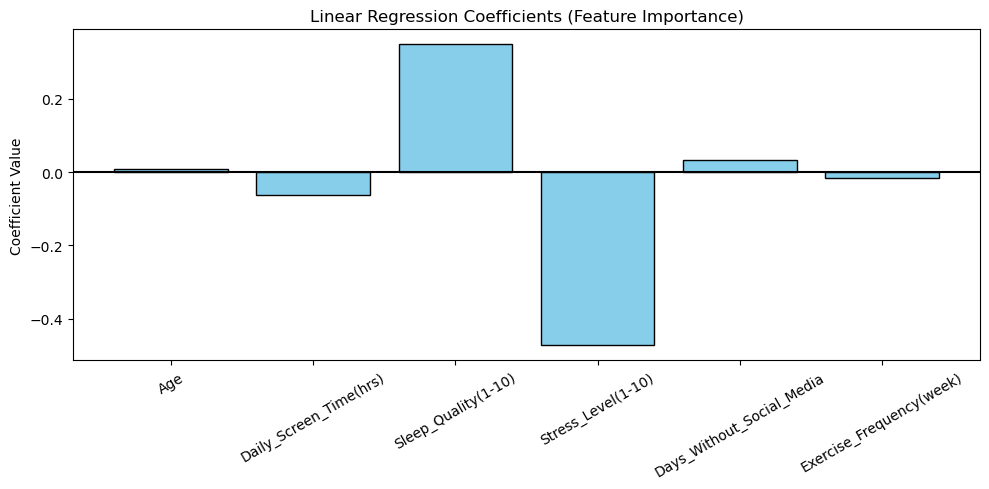

In [1]:
# Linear Regression Coefficients (Feature Importance)
# For your Mental Health dataset

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("Mental_Health_and_Social_Media_Balance_Dataset.csv")

# Convert categorical columns
df = pd.get_dummies(df, columns=['Social_Media_Platform'], drop_first=True)

# Gender encoding
df['Gender'] = df['Gender'].map({'Female':0, 'Male':1, 'Other':2})

# Features and target
X = df[['Age',
        'Daily_Screen_Time(hrs)',
        'Sleep_Quality(1-10)',
        'Stress_Level(1-10)',
        'Days_Without_Social_Media',
        'Exercise_Frequency(week)']]

y = df['Happiness_Index(1-10)']

# Train model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Plot coefficients
plt.figure(figsize=(10,5))
plt.bar(X.columns, model.coef_, color='skyblue', edgecolor='black')
plt.title("Linear Regression Coefficients (Feature Importance)")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=30)
plt.axhline(y=0, color='black')
plt.tight_layout()
plt.show()

Linear Regression using Stress_Level
R2 Score = 53.05 %


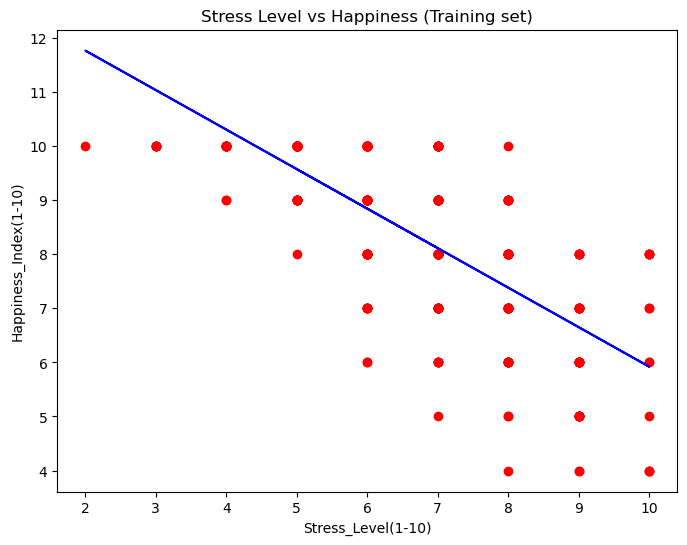

In [3]:
# BEST SINGLE VARIABLE = Stress_Level(1-10)
# Use ONLY one linear regression graph like your sample image

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("Mental_Health_and_Social_Media_Balance_Dataset.csv")

# X = highest variable
X = df[['Stress_Level(1-10)']].values

# y = target
y = df['Happiness_Index(1-10)'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predict
y_pred = regressor.predict(X_test)

# R2
r2 = r2_score(y_test, y_pred)
print("Linear Regression using Stress_Level")
print("R2 Score =", round(r2*100,2), "%")

# GRAPH (same sample style)
plt.figure(figsize=(8,6))
plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title("Stress Level vs Happiness (Training set)")
plt.xlabel("Stress_Level(1-10)")
plt.ylabel("Happiness_Index(1-10)")
plt.show()

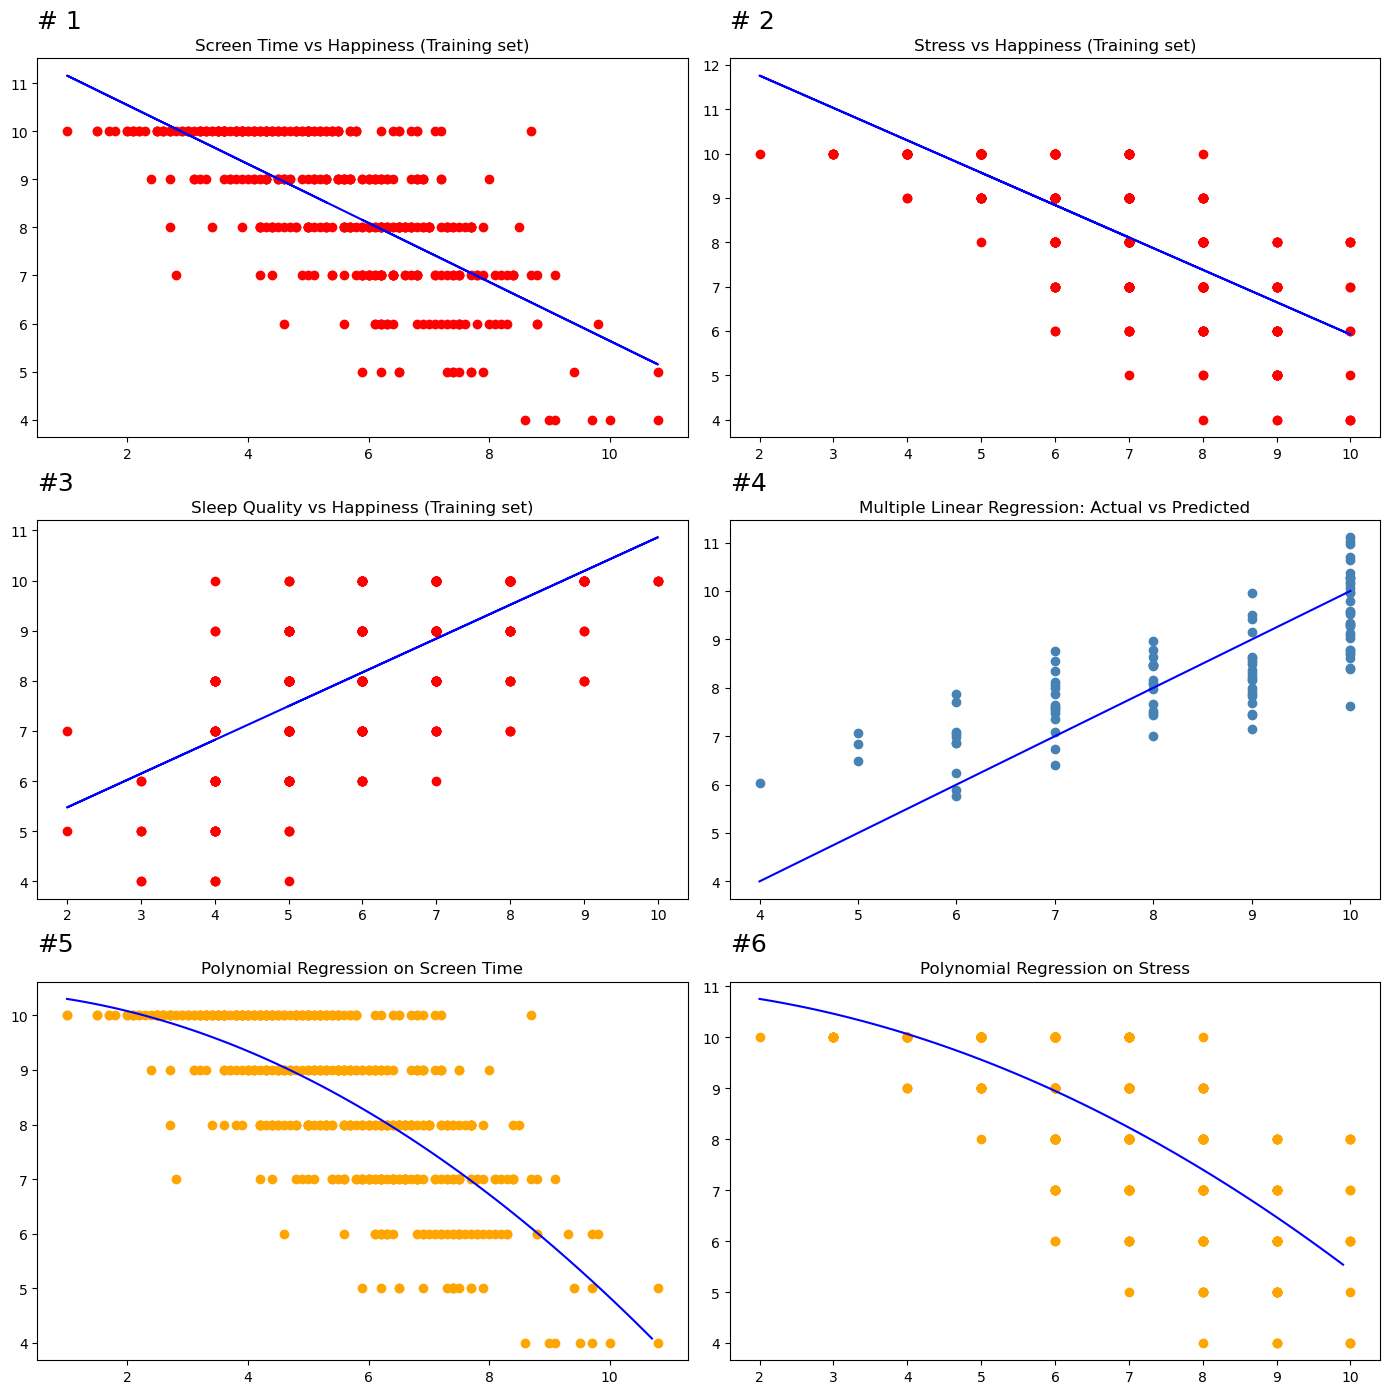

In [4]:
# SAME STYLE AS IMAGE YOU SENT
# 6 regression graphs for Mental Health dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("Mental_Health_and_Social_Media_Balance_Dataset.csv")

# -----------------------
# TARGET
# -----------------------
y = df["Happiness_Index(1-10)"].values

# -----------------------
# VARIABLES
# -----------------------
X1 = df[["Daily_Screen_Time(hrs)"]].values
X2 = df[["Stress_Level(1-10)"]].values
X3 = df[["Sleep_Quality(1-10)"]].values

# multilinear
df["Gender"] = df["Gender"].map({"Female":0,"Male":1,"Other":2})

X4 = df[[
    "Age",
    "Gender",
    "Daily_Screen_Time(hrs)",
    "Sleep_Quality(1-10)",
    "Stress_Level(1-10)",
    "Days_Without_Social_Media",
    "Exercise_Frequency(week)"
]].values


# -----------------------------------
# Linear #1
# -----------------------------------
X_train1,X_test1,y_train1,y_test1=train_test_split(X1,y,test_size=0.2,random_state=42)
reg1=LinearRegression()
reg1.fit(X_train1,y_train1)

# -----------------------------------
# Linear #2 (BEST = Stress)
# -----------------------------------
X_train2,X_test2,y_train2,y_test2=train_test_split(X2,y,test_size=0.2,random_state=42)
reg2=LinearRegression()
reg2.fit(X_train2,y_train2)

# -----------------------------------
# Linear #3
# -----------------------------------
X_train3,X_test3,y_train3,y_test3=train_test_split(X3,y,test_size=0.2,random_state=42)
reg3=LinearRegression()
reg3.fit(X_train3,y_train3)

# -----------------------------------
# Multilinear #4
# -----------------------------------
X_train4,X_test4,y_train4,y_test4=train_test_split(X4,y,test_size=0.2,random_state=42)
reg4=LinearRegression()
reg4.fit(X_train4,y_train4)
pred4=reg4.predict(X_test4)

# -----------------------------------
# Polynomial #5
# -----------------------------------
poly5=PolynomialFeatures(degree=2)
X_poly5=poly5.fit_transform(X1)
X_train5,X_test5,y_train5,y_test5=train_test_split(X_poly5,y,test_size=0.2,random_state=42)
reg5=LinearRegression()
reg5.fit(X_train5,y_train5)

# -----------------------------------
# Polynomial #6
# -----------------------------------
poly6=PolynomialFeatures(degree=2)
X_poly6=poly6.fit_transform(X2)
X_train6,X_test6,y_train6,y_test6=train_test_split(X_poly6,y,test_size=0.2,random_state=42)
reg6=LinearRegression()
reg6.fit(X_train6,y_train6)

# -----------------------------------
# PLOT EXACT STYLE
# -----------------------------------
fig, ax = plt.subplots(3,2, figsize=(14,14))

# #1
ax[0,0].scatter(X_train1, y_train1, color='red')
ax[0,0].plot(X_train1, reg1.predict(X_train1), color='blue')
ax[0,0].set_title("Screen Time vs Happiness (Training set)")
ax[0,0].text(0.0,1.08,"# 1", transform=ax[0,0].transAxes, fontsize=18)

# #2
ax[0,1].scatter(X_train2, y_train2, color='red')
ax[0,1].plot(X_train2, reg2.predict(X_train2), color='blue')
ax[0,1].set_title("Stress vs Happiness (Training set)")
ax[0,1].text(0.0,1.08,"# 2", transform=ax[0,1].transAxes, fontsize=18)

# #3
ax[1,0].scatter(X_train3, y_train3, color='red')
ax[1,0].plot(X_train3, reg3.predict(X_train3), color='blue')
ax[1,0].set_title("Sleep Quality vs Happiness (Training set)")
ax[1,0].text(0.0,1.08,"#3", transform=ax[1,0].transAxes, fontsize=18)

# #4
ax[1,1].scatter(y_test4, pred4, color='steelblue')
ax[1,1].plot([y.min(),y.max()],[y.min(),y.max()], color='blue')
ax[1,1].set_title("Multiple Linear Regression: Actual vs Predicted")
ax[1,1].text(0.0,1.08,"#4", transform=ax[1,1].transAxes, fontsize=18)

# #5
ax[2,0].scatter(X1, y, color='orange')
grid=np.arange(X1.min(),X1.max(),0.1).reshape(-1,1)
ax[2,0].plot(grid, reg5.predict(poly5.transform(grid)), color='blue')
ax[2,0].set_title("Polynomial Regression on Screen Time")
ax[2,0].text(0.0,1.08,"#5", transform=ax[2,0].transAxes, fontsize=18)

# #6
ax[2,1].scatter(X2, y, color='orange')
grid2=np.arange(X2.min(),X2.max(),0.1).reshape(-1,1)
ax[2,1].plot(grid2, reg6.predict(poly6.transform(grid2)), color='blue')
ax[2,1].set_title("Polynomial Regression on Stress")
ax[2,1].text(0.0,1.08,"#6", transform=ax[2,1].transAxes, fontsize=18)

plt.tight_layout()
plt.show()

Decision Tree Results
Accuracy : 0.596
Precision: 0.5942
Recall   : 0.596
F1-score : 0.5945

Confusion Matrix:
[[17  1  8]
 [ 0 19 10]
 [10 11 23]]


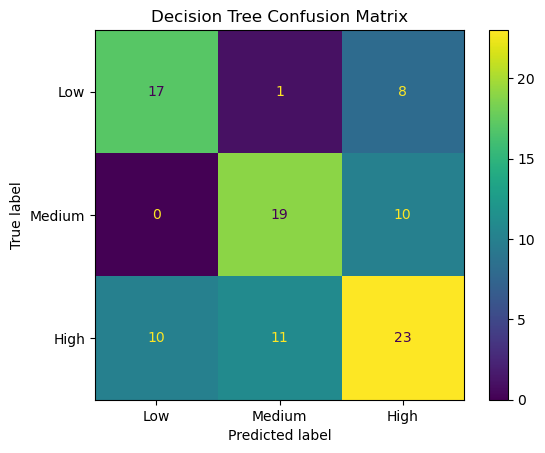

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1) Load dataset
df = pd.read_csv("Mental_Health_and_Social_Media_Balance_Dataset.csv")

# 2) Remove User_ID
df = df.drop(columns=["User_ID"])

# 3) Remove outliers using IQR
numeric_cols = [
    "Age",
    "Daily_Screen_Time(hrs)",
    "Sleep_Quality(1-10)",
    "Stress_Level(1-10)",
    "Days_Without_Social_Media",
    "Exercise_Frequency(week)"
]
outlier_indices = set()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    idx = df[(df[col] < lower) | (df[col] > upper)].index
    outlier_indices.update(idx)

df = df.drop(index=list(outlier_indices)).reset_index(drop=True)

# 4) Encode Gender
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1, "Other": 2})

# 5) One-hot encode Social_Media_Platform
df = pd.get_dummies(df, columns=["Social_Media_Platform"], drop_first=False)

# 6) Create revised happiness classes
df["Happiness_Category"] = pd.cut(
    df["Happiness_Index(1-10)"],
    bins=[3.999, 7, 9, 10],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)
# 7) Select X and y
X = df.drop(columns=["Happiness_Index(1-10)", "Happiness_Category"])
y = df["Happiness_Category"]

# 8) Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 9) Train Decision Tree
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

# 10) Predict
y_pred = classifier.predict(X_test)

# 11) Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
print("Decision Tree Results")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

# 12) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"])
disp.plot(cmap="viridis")
plt.title("Decision Tree Confusion Matrix")
plt.show()

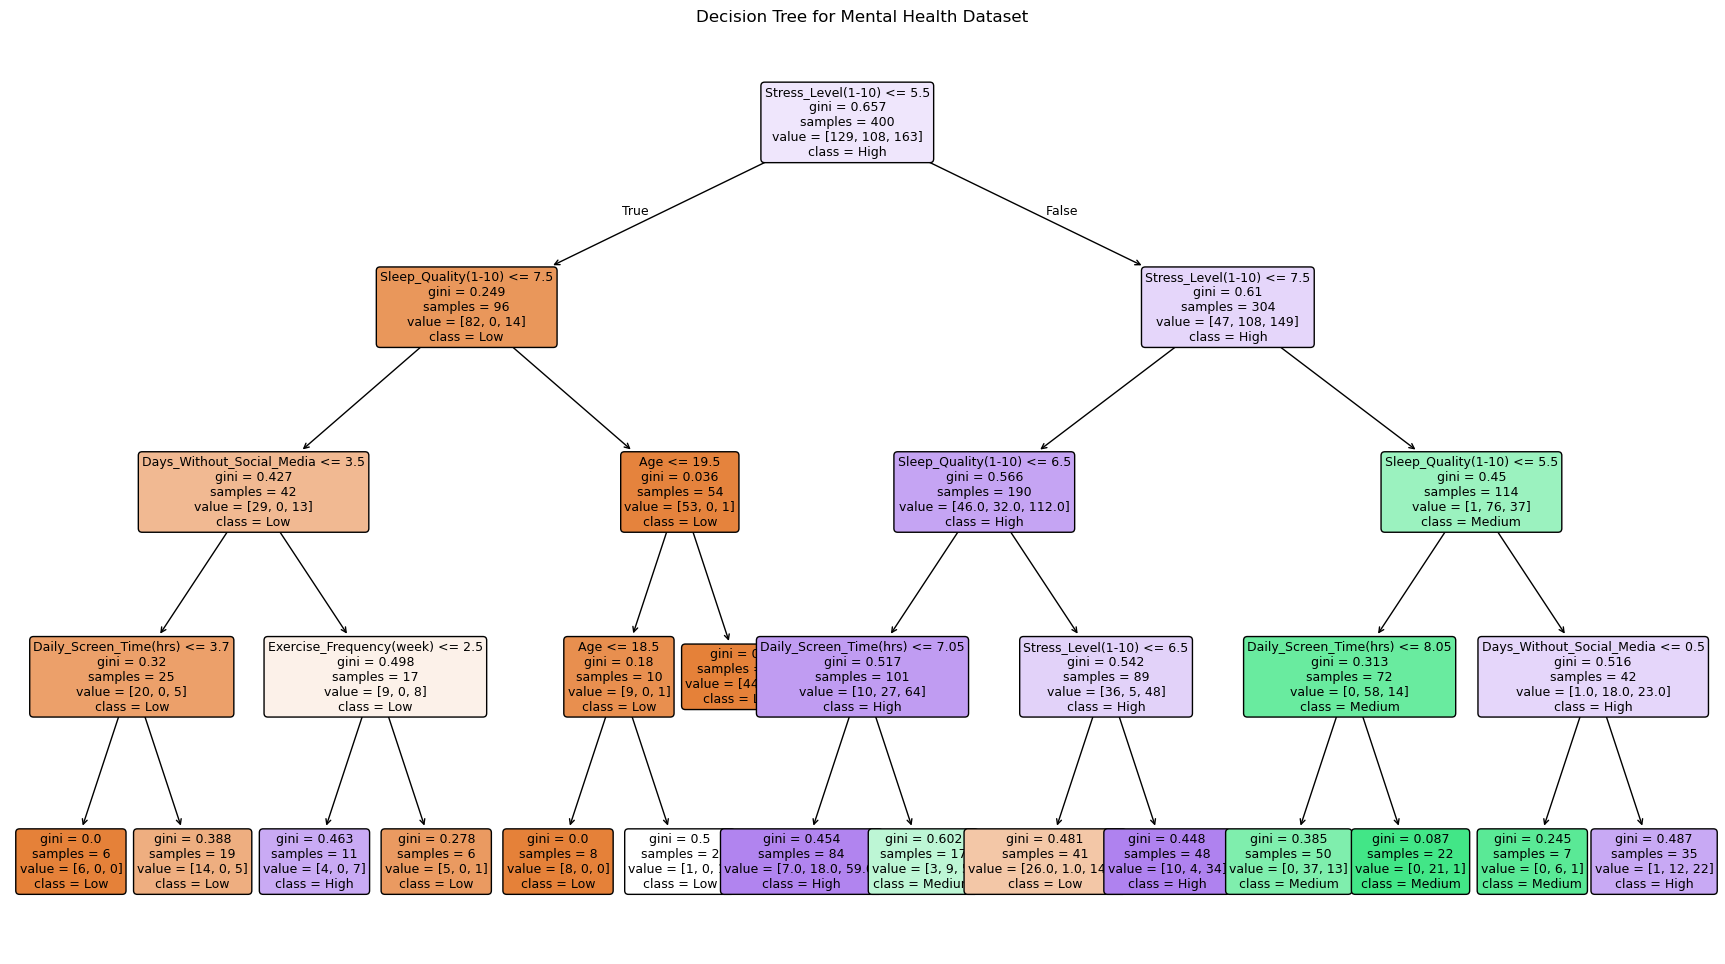

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Load dataset
df = pd.read_csv("Mental_Health_and_Social_Media_Balance_Dataset.csv")

# Remove ID
df = df.drop(columns=["User_ID"])

# Encode Gender
df["Gender"] = df["Gender"].map({"Female":0, "Male":1, "Other":2})

# One-hot encode platform
df = pd.get_dummies(df, columns=["Social_Media_Platform"], drop_first=False)

# Create happiness classes
df["Happiness_Category"] = pd.cut(
    df["Happiness_Index(1-10)"],
    bins=[3.999,7,9,10],
    labels=["Low","Medium","High"],
    include_lowest=True
)
X = df.drop(columns=["Happiness_Index(1-10)", "Happiness_Category"])
y = df["Happiness_Category"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train tree
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Draw tree
plt.figure(figsize=(22,12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Low","Medium","High"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree for Mental Health Dataset")
plt.show()

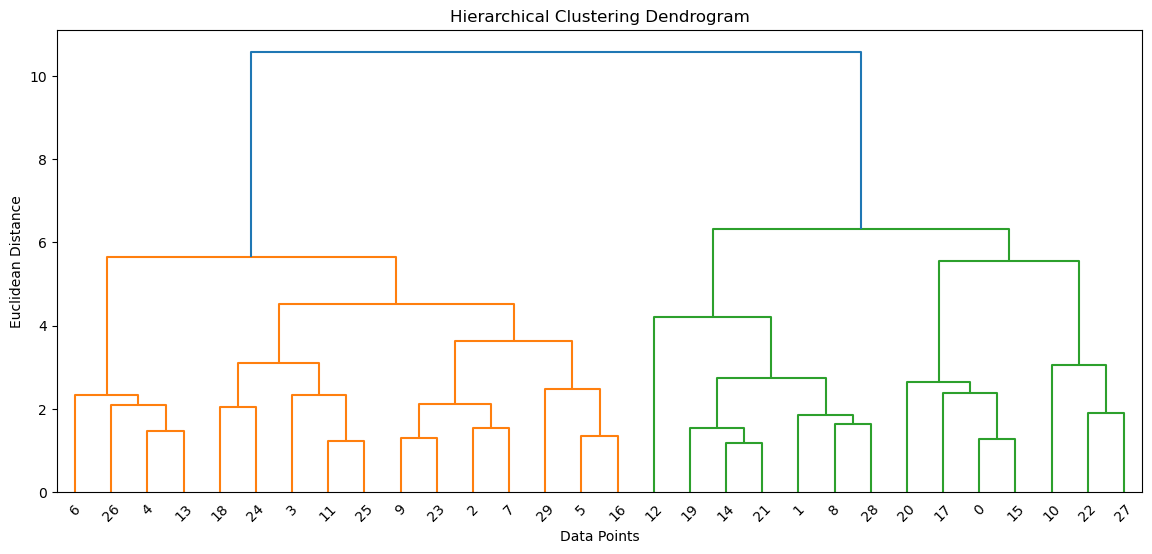

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

# Load dataset
df = pd.read_csv("Mental_Health_and_Social_Media_Balance_Dataset.csv")

# Take only 30 rows (VERY IMPORTANT)
df = df.head(30)

# Features
X = df[['Daily_Screen_Time(hrs)',
        'Sleep_Quality(1-10)',
        'Stress_Level(1-10)',
        'Days_Without_Social_Media',
        'Exercise_Frequency(week)',
        'Happiness_Index(1-10)']]

# Scale
X_scaled = StandardScaler().fit_transform(X)

# Linkage
Z = linkage(X_scaled, method='ward')
# Plot
plt.figure(figsize=(14,6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()
